# PCI on a dynamical SIR model with policies

This notebook runs *probabilistic causal impacts* (PCI) on a Bayesian SIR model with two
non-pharmaceutical policies whose effects interact: lockdown and mask-wearing. The
model and the query come from the chirho tutorial on
[explainable reasoning in dynamical systems][chirho-sir], which scores candidate causes
with chirho's `SearchForExplanation` handler. We keep both and swap in the thin-search
sampler from `pci.explanation`, which returns a continuous score carrying a necessity
and a sufficiency term.

 We build the epidemic model, watch a but-for analysis fail to separate the two
policies, and then ask what PCI adds. PCI ranks lockdown above mask on the factual
world used throughout, keeps that ranking in $18$ of $20$ worlds drawn at other
operating points.

[chirho-sir]: https://basisresearch.github.io/chirho/explainable_sir.html

## Setup and notebook conventions

The cell below imports the SIR machinery from
[chirho](https://basisresearch.github.io/chirho/) (the `dynamical` handlers that
integrate the ODE and log trajectories) together with the thin-search components from
`pci.explanation`: `SearchableModel` and `ThinSearchSampler` drive the search over
interventional regimes, while `abs_diff_score` and `condition_on_interventional_regime`
turn sampled regimes into necessity and sufficiency scores.

In [1]:
import contextlib
import numbers
import os
import pickle
import sys
from typing import TypeVar, cast

import matplotlib.pyplot as plt
import pandas as pd
import pyro
import pyro.distributions as dist
import seaborn as sns
import torch
from chirho.dynamical.handlers.interruption import StaticEvent
from chirho.dynamical.handlers.solver import TorchDiffEq
from chirho.dynamical.handlers.trajectory import LogTrajectory
from chirho.dynamical.ops import Dynamics, State, on, simulate
from chirho.interventional.ops import Intervention, intervene
from chirho.observational.handlers import condition
from loguru import logger
from pyro.infer import Predictive

from pci.explanation.regime import condition_on_interventional_regime
from pci.explanation.scores import abs_diff_score
from pci.explanation.searchable import SearchableModel
from pci.explanation.thin_search import ThinSearchSampler
from pci.tools.find_root import find_repo_root

R = numbers.Real | torch.Tensor
T = TypeVar("T")

smoke_test = "CI" in os.environ
root = find_repo_root()
results_dir = os.path.join(root, "docs/source/dynamical_benchmark")
fig_dir = os.path.join(root, "docs/source/sir_benchmark")
print(f"Results will be saved to {results_dir}")

# The sampler warns through loguru when a sampled alternative lands too close
# to the factual value; the tqdm bars carry the rest of the progress reporting.
logger.remove()
logger.add(sys.stderr, level="INFO")

num_worlds_at_site = 2 if smoke_test else 20  # factual worlds in the robustness run

# flip to True to recompute the searches and overwrite the cached results
fresh_run = False

seed = 123
pyro.clear_param_store()
pyro.set_rng_seed(seed)

sns.set_style("white")

# Paper-grade matplotlib defaults
plt.rcParams.update(
    {
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "savefig.dpi": 160,
        "savefig.bbox": "tight",
    }
)

Results will be saved to /home/rafal/s76projects/explainable_paper/docs/source/dynamical_benchmark


## SIR model with policies

We use the standard SIR dynamics

$$\dot S = -\beta S I, \qquad \dot I = \beta S I - \gamma I, \qquad \dot R = \gamma I,$$

with a parameterised variant `SIRDynamicsPolicies` that adds an intervention strength
$l \in [0, 1]$ scaling the transmission rate to $(1 - l)\beta_0$. At $l = 0$ the model
reduces to the unparameterised dynamics. The dynamics are deterministic, so
stochasticity enters only through the priors over $\beta$ and $\gamma$; we take the
structural model as correctly specified and assume no unobserved confounding between
the parameters.

The outcome of interest is the *overshoot*: how far the susceptible count falls between the
infectious peak and the end of the run, that is, how many people catch the disease
after the peak has passed.The next cell reports units as a fraction of
the population ($0.151$), but the model's `overshoot_query` reports the same quantity
in people, which is the unit the threshold uses. The unintervened epidemic therefore
overshoots by about $15$ people out of $100$, below the $24$ we treat as the
undesirable outcome.

In [2]:
class SIRDynamics(pyro.nn.PyroModule):
    def __init__(self, beta, gamma):
        super().__init__()
        self.beta = beta
        self.gamma = gamma

    def forward(self, X: State[torch.Tensor]):
        dX: State[torch.Tensor] = dict()
        dX["S"] = -self.beta * X["S"] * X["I"]
        dX["I"] = self.beta * X["S"] * X["I"] - self.gamma * X["I"]
        dX["R"] = self.gamma * X["I"]

        return dX


class SIRDynamicsPolicies(SIRDynamics):
    def __init__(self, beta0, gamma):
        super().__init__(beta0, gamma)
        self.beta0 = beta0

    def forward(self, X: State[torch.Tensor]):
        self.beta = (1 - X["l"]) * self.beta0
        dX = super().forward(X)
        dX["l"] = torch.zeros_like(X["l"])
        return dX

In [3]:
total_population = 100
init_state = dict(S=torch.tensor(99.0), I=torch.tensor(1.0), R=torch.tensor(0.0))
assert init_state["S"] + init_state["I"] + init_state["R"] == total_population

start_time = torch.tensor(0.0)
end_time = torch.tensor(12.0)
step_size = torch.tensor(0.1)
logging_times = torch.arange(start_time, end_time, step_size)  # type: ignore[call-overload]  # torch.arange accepts 0-d tensors at runtime
init_state_lockdown = dict(**init_state, l=torch.tensor(0.0))

beta_true = torch.tensor([0.03])
gamma_true = torch.tensor([0.5])
sir_true = SIRDynamics(beta_true, gamma_true)
with TorchDiffEq(), LogTrajectory(logging_times) as lt:
    simulate(sir_true, init_state, start_time, end_time)

sir_true_traj = lt.trajectory


def get_overshoot(trajectory):
    t_max = torch.argmax(trajectory["I"].squeeze())
    S_peak = trajectory["S"].squeeze()[t_max] / total_population
    S_final = trajectory["S"].squeeze()[-1] / total_population
    return (S_peak - S_final).item()


print(get_overshoot(sir_true_traj))

0.15116800367832184


### Bayesian SIR with priors

We put Beta priors on the rates: $\beta \sim \mathrm{Beta}(18, 600)$ and
$\gamma \sim \mathrm{Beta}(1600, 1600)$, centred near $0.03$ and $0.5$.

### Policies and asymmetric efficiencies

Two policies, each with prior probability $1/2$, can be enacted: lockdown at $t=1$ and
masking at $t=1.5$. Their efficiencies interact asymmetrically. Lockdown alone has
efficiency $0.6$. Masking is worth $0.45$ on its own but only $0.1$ under lockdown,
since a lockdown has already removed most of the contacts a mask would block. The joint
efficiency is the sum of the two, clamped at $0.95$; with both policies on that sum is
$0.6 + 0.1 = 0.7$.

Interventions go through `MaskedStaticIntervention` to avoid trace conflicts.
`overshoot_query` reads the overshoot off the logged trajectory and flags
$\mathrm{os\_too\_high} = \mathbb{1}[\mathrm{overshoot} > 24]$.

In [4]:
def bayesian_sir(
    base_model=SIRDynamics, plate: pyro.plate | None = None
) -> Dynamics[torch.Tensor]:
    # Beta(18, 600) and Beta(1600, 1600) have scalar parameters, so outside a
    # plate they yield one draw shared by the whole batch. Inside one they are
    # drawn per batch element, which is what lets a batch of factual worlds
    # differ in its operating point and not only in its policy decisions.
    with plate if plate is not None else contextlib.nullcontext():
        beta = pyro.sample("beta", dist.Beta(18, 600))
        gamma = pyro.sample("gamma", dist.Beta(1600, 1600))
    sir = base_model(beta, gamma)
    return sir

In [5]:
# Intervene on a dynamical system nested inside another model. The block()
# keeps the intervention off the trace, where the site name already exists.


def MaskedStaticIntervention[T](time: R, intervention: Intervention[State[T]]):

    @on(StaticEvent(time))
    def callback(
        dynamics: Dynamics[T], state: State[T]
    ) -> tuple[Dynamics[T], State[T]]:

        with pyro.poutine.block():
            return dynamics, intervene(state, intervention)

    return callback

In [6]:
overshoot_threshold = 24
lockdown_time = torch.tensor(1.0)
mask_time = torch.tensor(1.5)


def policy_model() -> State[torch.Tensor]:

    lockdown = pyro.sample("lockdown", dist.Bernoulli(torch.tensor(0.5)))
    mask = pyro.sample("mask", dist.Bernoulli(torch.tensor(0.5)))

    lockdown_efficiency = pyro.deterministic(
        "lockdown_efficiency", torch.tensor(0.6) * lockdown, event_dim=0
    )

    mask_efficiency = pyro.deterministic(
        "mask_efficiency", (0.1 * lockdown + 0.45 * (1 - lockdown)) * mask, event_dim=0
    )

    joint_efficiency = pyro.deterministic(
        "joint_efficiency",
        torch.clamp(lockdown_efficiency + mask_efficiency, 0, 0.95),
        event_dim=0,
    )

    lockdown_sir = bayesian_sir(SIRDynamicsPolicies)
    with LogTrajectory(logging_times, is_traced=True) as lt:
        with TorchDiffEq():
            with MaskedStaticIntervention(lockdown_time, dict(l=lockdown_efficiency)):
                with MaskedStaticIntervention(mask_time, dict(l=joint_efficiency)):
                    simulate(
                        lockdown_sir, init_state_lockdown, start_time, logging_times[-1]
                    )

    return lt.trajectory


def overshoot_query(
    trajectory: State[torch.Tensor],
) -> tuple[torch.Tensor, torch.Tensor]:

    t_max = torch.max(trajectory["I"], dim=-1).indices
    S_peaks = pyro.ops.indexing.Vindex(trajectory["S"])[..., t_max]
    overshoot = pyro.deterministic(
        "overshoot", S_peaks - trajectory["S"][..., -1], event_dim=0
    )
    os_too_high = pyro.deterministic(
        "os_too_high",
        (overshoot > overshoot_threshold).clone().detach().float(),
        event_dim=0,
    )

    return overshoot, os_too_high


def overshoot_model():
    trajectory = policy_model()
    return overshoot_query(trajectory)

## But-for analysis

The classical but-for query comes first: condition on each pair of policy decisions
(`(0,0)`, `(1,1)`, `(0,1)`, `(1,0)`) and draw $100$ predictive samples from each. Each
scenario gives a marginal distribution over the overshoot, which the figure summarises
by $\Pr(\mathrm{overshoot} > 24)$. At $100$ draws the Monte Carlo standard error on
each of those probabilities is about $0.04$, which matters for reading the four panels.

In [7]:
num_samples = 100

# The policy decisions are upstream of the dynamics, so conditioning them
# propagates the change through the trajectory.

overshoot_model_none = condition(
    overshoot_model, {"lockdown": torch.tensor(0.0), "mask": torch.tensor(0.0)}
)
unintervened_predictive = Predictive(
    overshoot_model_none, num_samples=num_samples, parallel=True
)
unintervened_samples = unintervened_predictive()

overshoot_model_all = condition(
    overshoot_model, {"lockdown": torch.tensor(1.0), "mask": torch.tensor(1.0)}
)
intervened_predictive = Predictive(
    overshoot_model_all, num_samples=num_samples, parallel=True
)
intervened_samples = intervened_predictive()

overshoot_model_mask = condition(
    overshoot_model, {"lockdown": torch.tensor(0.0), "mask": torch.tensor(1.0)}
)
mask_predictive = Predictive(
    overshoot_model_mask, num_samples=num_samples, parallel=True
)
mask_samples = mask_predictive()

overshoot_model_lockdown = condition(
    overshoot_model, {"lockdown": torch.tensor(1.0), "mask": torch.tensor(0.0)}
)
lockdown_predictive = Predictive(
    overshoot_model_lockdown, num_samples=num_samples, parallel=True
)
lockdown_samples = lockdown_predictive()

predictive = Predictive(overshoot_model, num_samples=num_samples, parallel=True)
samples = predictive()

print("Variables in the model:", samples.keys())

Variables in the model: dict_keys(['lockdown', 'mask', 'beta', 'gamma', 'lockdown_efficiency', 'mask_efficiency', 'joint_efficiency', 'S', 'I', 'R', 'l', 'overshoot', 'os_too_high'])


Saved /home/rafal/s76projects/explainable_paper/docs/source/sir_benchmark/sir_butfor.png
but-for: Pr(overshoot > 24) by regime
  no interventions             0.07
  both interventions           0.76
  lockdown only                0.84
  mask only                    0.81


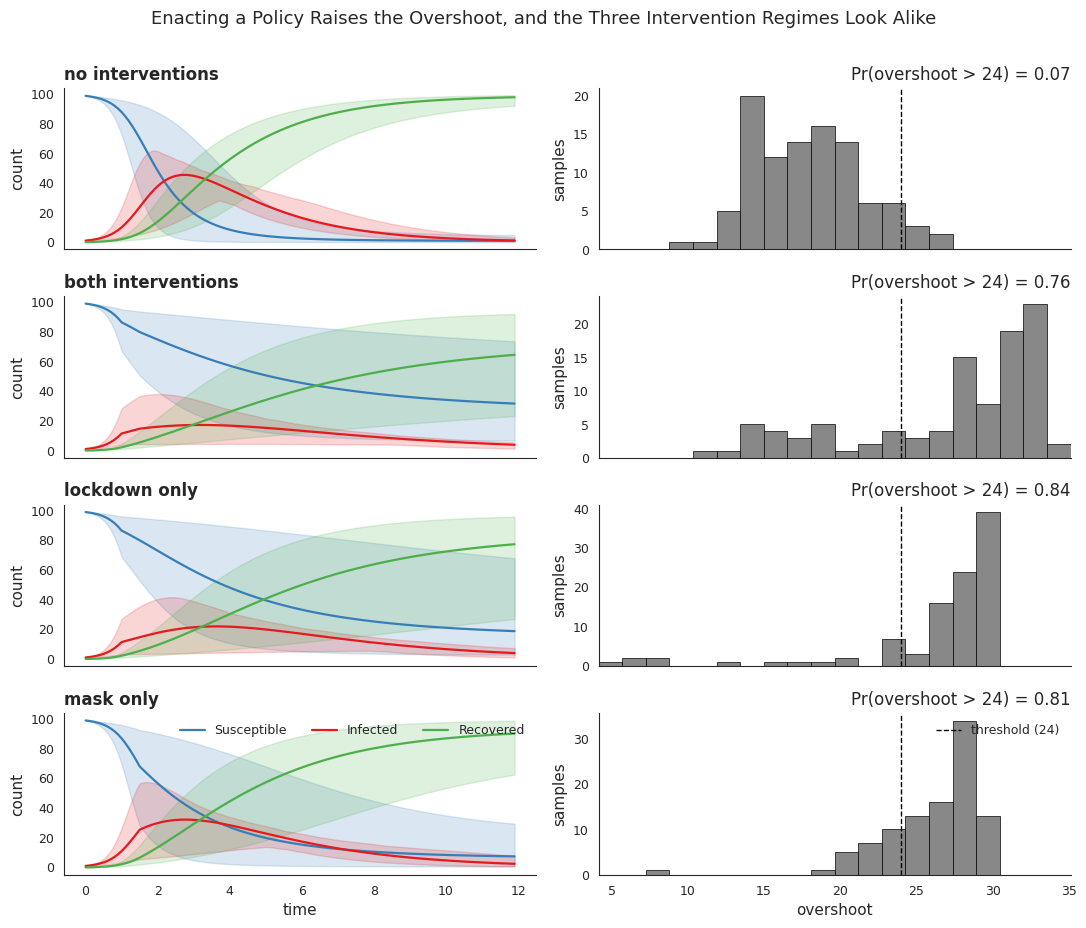

In [8]:
# Figure 1: but-for analysis, 4 scenarios x 2 panels
# (trajectory on the left, overshoot histogram on the right).
# The "stochastic" prior-mixture case is dropped from this figure for clarity.

# SIR palette (color-blind safe).
sir_colors = {"S": "#377eb8", "I": "#e41a1c", "R": "#4daf4a"}


def _add_traj(preds, ax, color, label):
    sns.lineplot(
        x=logging_times,
        y=preds.mean(dim=0).squeeze().tolist(),
        ax=ax,
        label=label,
        color=color,
        linewidth=1.6,
    )
    ax.fill_between(
        logging_times,
        torch.quantile(preds, 0.025, dim=0).squeeze(),
        torch.quantile(preds, 0.975, dim=0).squeeze(),
        alpha=0.18,
        color=color,
    )


scenarios = [
    ("no interventions", unintervened_samples),
    ("both interventions", intervened_samples),
    ("lockdown only", lockdown_samples),
    ("mask only", mask_samples),
]

n_rows = len(scenarios)
fig, axs = plt.subplots(n_rows, 2, figsize=(11, 2.3 * n_rows), sharex="col")

# common overshoot x-range across the histogram column
all_overshoot = (
    torch.cat([s["overshoot"].squeeze().flatten() for _, s in scenarios])
    .detach()
    .cpu()
    .numpy()
)
hist_lo, hist_hi = float(all_overshoot.min()), float(all_overshoot.max())
hist_pad = 0.05 * (hist_hi - hist_lo + 1e-9)
hist_lo -= hist_pad
hist_hi += hist_pad

butfor_rows: list[tuple[str, float]] = []
for i, (label, samples_i) in enumerate(scenarios):
    ax_traj = axs[i, 0]
    _add_traj(samples_i["S"], ax_traj, sir_colors["S"], "Susceptible")
    _add_traj(samples_i["I"], ax_traj, sir_colors["I"], "Infected")
    _add_traj(samples_i["R"], ax_traj, sir_colors["R"], "Recovered")
    ax_traj.set_title(label, loc="left", fontweight="bold")
    ax_traj.set_ylabel("count")
    if i < n_rows - 1 and ax_traj.get_legend() is not None:
        ax_traj.get_legend().remove()
    else:
        ax_traj.legend(loc="upper right", ncol=3, frameon=False)
    if i == n_rows - 1:
        ax_traj.set_xlabel("time")

    ax_hist = axs[i, 1]
    o = samples_i["overshoot"].squeeze().detach().cpu().numpy()
    pr_too_high = float(samples_i["os_too_high"].squeeze().float().mean().item())
    butfor_rows.append((label, pr_too_high))
    ax_hist.hist(
        o,
        bins=20,
        range=(hist_lo, hist_hi),
        color="#888888",
        edgecolor="black",
        linewidth=0.5,
    )
    ax_hist.axvline(
        overshoot_threshold,
        color="black",
        linestyle="--",
        linewidth=1.0,
        label=f"threshold ({overshoot_threshold})",
    )
    ax_hist.set_title(
        f"Pr(overshoot > {overshoot_threshold}) = {pr_too_high:.2f}",
        loc="right",
    )
    ax_hist.set_xlim(hist_lo, hist_hi)
    ax_hist.set_ylabel("samples")
    if i == n_rows - 1:
        ax_hist.set_xlabel("overshoot")
        ax_hist.legend(loc="upper right", frameon=False)

fig.suptitle(
    "Enacting a Policy Raises the Overshoot, and the Three Intervention Regimes Look Alike",
    fontsize=13,
    y=1.005,
)
plt.tight_layout()
sns.despine()

if not smoke_test:
    os.makedirs(fig_dir, exist_ok=True)
    fig.savefig(os.path.join(fig_dir, "sir_butfor.png"))
    print(f"Saved {os.path.join(fig_dir, 'sir_butfor.png')}")

print(f"but-for: Pr(overshoot > {overshoot_threshold}) by regime")
for label, p in butfor_rows:
    print(f"  {label:<28s} {p:.2f}")


Enacting a policy makes the bad outcome more likely. Without intervention
$\Pr(\mathrm{overshoot} > 24) \approx 0.07$, with both policies it is $0.76$, with lockdown
only $0.84$, and with mask only $0.81$. The three intervention regimes fall within
about two Monte Carlo standard errors of one another and their histograms overlap
heavily, so at $100$ draws this experiment separates intervention from no intervention
and nothing finer. A but-for verdict built on these numbers cannot rank lockdown
against mask.

Why does suppressing transmission raise the overshoot at all? The cell below answers by
holding $\beta$ and $\gamma$ at their prior means and simulating each policy
configuration deterministically, which strips out the prior noise and leaves the
mechanism.

In [9]:
def deterministic_overshoot(lockdown_eff: float, joint_eff: float) -> float:
    """Overshoot at the prior-mean rates, for one (lockdown, joint) efficiency pair."""
    sir = SIRDynamicsPolicies(torch.tensor([0.03]), torch.tensor([0.5]))
    with LogTrajectory(logging_times) as lt_det:
        with TorchDiffEq():
            with MaskedStaticIntervention(
                lockdown_time, dict(l=torch.tensor(lockdown_eff))
            ):
                with MaskedStaticIntervention(
                    mask_time, dict(l=torch.tensor(joint_eff))
                ):
                    simulate(sir, init_state_lockdown, start_time, logging_times[-1])
    traj = lt_det.trajectory
    t_peak = int(torch.argmax(traj["I"].squeeze()))
    return float(traj["S"].squeeze()[t_peak] - traj["S"].squeeze()[-1])


efficiency_rows = [
    ("no policies", 0.0, 0.0),
    ("mask only", 0.0, 0.45),
    ("lockdown only", 0.6, 0.6),
    ("both policies", 0.6, 0.7),
    ("(unreachable) at the 0.95 cap", 0.6, 0.95),
]

print(f"{'configuration':32s} {'joint efficiency':>16s} {'overshoot':>10s}")
for label, l_eff, j_eff in efficiency_rows:
    print(f"{label:32s} {j_eff:16.2f} {deterministic_overshoot(l_eff, j_eff):10.2f}")

configuration                    joint efficiency  overshoot
no policies                                  0.00      15.12


mask only                                    0.45      26.28
lockdown only                                0.60      30.19


both policies                                0.70      31.13
(unreachable) at the 0.95 cap                0.95       4.16


Over the whole range this model can reach, the overshoot grows with the strength of
suppression: $15.1$ people with no policy, $26.3$ under masking alone, $30.2$ under
lockdown alone, $31.1$ under both. Slowing transmission delays the infectious peak and
leaves more susceptibles standing when it arrives, and those susceptibles catch the
disease on the way down. Reversing the pattern takes suppression strong enough to
truncate the epidemic at the moment the policy lands, which the last row shows at the
unreachable $0.95$: the peak falls back to $t=1.5$ and the overshoot collapses to
$4.2$. Since the joint efficiency tops out at $0.7$, both policies operate on the
rising part of that curve.

As long as we use flat but-for tests, lockdown alone ($0.6$) and both policies ($0.7$)
differ by a tenth of an efficiency unit, because masking adds only $0.1$ once lockdown
is in force, and once $\beta$ and $\gamma$ are drawn from their priors the resulting
overshoot distributions overlap. But-for analysis treats each policy as a binary cause
and reports an aggregate effect, with no way to say that masking's contribution depends
on whether lockdown is in force.

## Causal explanations with PCI thin search

We will explore *interventional regimes*, joint assignments of antecedents (where 
to intervene), witnesses (where to hold factual values) and an outcome.
Each regime is scored with the **impact kernel**
$|y^\star - y_{\mathrm{nec}}| - |y^\star - y_{\mathrm{suff}}|$. Its necessity term rewards
regimes where removing the suspect moves the outcome away from the factual value
$y^\star$; its sufficiency term rewards regimes where holding the suspect at its factual
value keeps the outcome close to $y^\star$.

The suspects are lockdown and mask, and the sampler may use the three efficiency sites
(`lockdown_efficiency`, `mask_efficiency`, `joint_efficiency`) as witnesses. The
factual world has both policies on, which fixes $y^\star = 33.19$ (for this seed), well
above the $24$ threshold. For each suspect the sampler draws $2{,}500$ regimes that put
the suspect in the antecedent set and keep it out of the witness set.

`policy_model` is fine for forward simulation, but thin search needs a model it can run
in batches and intervene on per regime. The cell below restates it in that form: it
samples the categorical suspects per regime, recomputes the three efficiency sites from
them, and simulates the trajectory so `overshoot` can be read off as the outcome. The
same code path conditions on a fixed factual world, which is how $y^\star$ is obtained
before any search begins.

For each regime the sampler builds two worlds. In the necessity world the focal suspect
takes its alternative value (lockdown off, say), any other active suspects are
intervened, and the witnesses are pinned at factual; its overshoot is
$y_{\mathrm{nec}}$. In the sufficiency world the focal suspect keeps its factual value,
with the same treatment of the others; its overshoot is $y_{\mathrm{suff}}$. The score
compares the two.

Both worlds run at the same draw of the rate parameters. `SearchableModel` is told
that `beta` and `gamma` are shared noise sites, so the necessity world reuses the
values the sufficiency world drew. Otherwise the two overshoots would come from two
different epidemics and their difference would measure the spread of the priors rather
than anything about the suspect. The rates are still redrawn for each regime, which is
what integrating over the prior amounts to here.

In [10]:
def searchable_overshoot_model(
    kwargs_iterable=[
        {"observations_dict": None, "n_size": 1},
        dict(),
        dict(),
    ],
):
    batch_size = int(kwargs_iterable[0]["n_size"])
    observations_dict = kwargs_iterable[0].get("observations_dict", None)

    obs_data = None
    if observations_dict is not None:
        obs_data = observations_dict.get("continuous", {}) | observations_dict.get(
            "categorical", {}
        )

    # ensure tensors have shape [..., batch, padding, event] = [batch, 1, 1]
    def _expand_scalar(x: torch.Tensor) -> torch.Tensor:
        return x.expand(batch_size, 1, 1)

    init_state_batched = {
        "S": _expand_scalar(init_state["S"]),
        "I": _expand_scalar(init_state["I"]),
        "R": _expand_scalar(init_state["R"]),
        "l": _expand_scalar(torch.tensor(0.0)),
    }

    # One factual world per batch element. The categorical policies carry that
    # dimension in their own logits; the rate priors need the plate to get it.
    worlds = pyro.plate("rate_worlds", batch_size, dim=-3)

    with condition(data=obs_data) if obs_data is not None else contextlib.nullcontext():
        logits01 = torch.ones(batch_size, 1, 1, 2)
        lockdown = pyro.sample("lockdown", dist.Categorical(logits=logits01))
        mask = pyro.sample("mask", dist.Categorical(logits=logits01))

        lockdown_f = lockdown.float()
        mask_f = mask.float()

        lockdown_efficiency = pyro.deterministic(
            "lockdown_efficiency", torch.tensor(0.6) * lockdown_f, event_dim=0
        )

        mask_efficiency = pyro.deterministic(
            "mask_efficiency",
            (0.1 * lockdown_f + 0.45 * (1 - lockdown_f)) * mask_f,
            event_dim=0,
        )

        joint_efficiency = pyro.deterministic(
            "joint_efficiency",
            torch.clamp(lockdown_efficiency + mask_efficiency, 0, 0.95),
            event_dim=0,
        )

        lockdown_sir = bayesian_sir(SIRDynamicsPolicies, plate=worlds)
        with LogTrajectory(logging_times, is_traced=True) as lt:
            with TorchDiffEq():
                with MaskedStaticIntervention(
                    lockdown_time, dict(l=lockdown_efficiency)
                ):
                    with MaskedStaticIntervention(mask_time, dict(l=joint_efficiency)):
                        simulate(
                            lockdown_sir,
                            init_state_batched,
                            start_time,
                            logging_times[-1],
                        )

        return overshoot_query(lt.trajectory)


suspects = ["lockdown", "mask"]
sites_of_interest = suspects + [
    "lockdown_efficiency",
    "mask_efficiency",
    "joint_efficiency",
]

searchable_model = SearchableModel(
    structured_model=searchable_overshoot_model,
    sites_of_interest=sites_of_interest,
    suspects=suspects,
    # The rate parameters are the model's exogenous noise: the necessity and
    # sufficiency worlds of one regime must be evaluated at the same draw, or
    # the paired score compares two different epidemics.
    shared_noise_sites=["beta", "gamma"],
    outcome_variable="overshoot",
)

# a single factual world (batch_size = 1)
# NOTE: if you edit obs_dict, also flip fresh_run=True (or change seed) so the
# cache is not silently reused.
obs_dict = {
    "continuous": {
        "lockdown_efficiency": torch.tensor([[[0.6]]]),
        "mask_efficiency": torch.tensor([[[0.1]]]),
        "joint_efficiency": torch.tensor([[[0.7]]]),
    },
    "categorical": {
        "lockdown": torch.tensor([[[1]]], dtype=torch.long),
        "mask": torch.tensor([[[1]]], dtype=torch.long),
    },
}

sampler = ThinSearchSampler(
    structured_model=searchable_model,
    conditioned_alternatives=True,
    factual_exclusion=True,
    max_antecedents=4,
    max_witnesses_dropped=4,
)

num_search_samples = 5 if smoke_test else 2_500

cache_path = os.path.join(
    results_dir, f"search_single_n{num_search_samples}_seed{seed}.pkl"
)

if (not smoke_test) and (not fresh_run) and os.path.exists(cache_path):
    with open(cache_path, "rb") as f:
        search_results, factual_overshoot = pickle.load(f)
    print(f"Loaded cache {cache_path}")
else:
    search_results = sampler.sample(obs_dict, num_samples=num_search_samples)

    # Factual outcome y* for scoring (computed under the factual lockdown/mask values)
    with torch.no_grad():
        with pyro.poutine.trace() as tr_factual:
            searchable_overshoot_model(
                kwargs_iterable=[
                    {"observations_dict": obs_dict, "n_size": 1},
                    {},
                    {},
                ]
            )

    factual_overshoot = cast(
        torch.Tensor, tr_factual.trace.nodes["overshoot"]["value"]
    ).detach()

    if not smoke_test:
        os.makedirs(results_dir, exist_ok=True)
        with open(cache_path, "wb") as f:  # type: ignore[assignment]  # f rebound to writer in else-branch
            pickle.dump((search_results, factual_overshoot), f)
        print(f"Wrote cache {cache_path}")

suspect_score_means = {}
for suspect_name in suspects:
    suspect_sample = condition_on_interventional_regime(
        results_dictionary=search_results,
        reference_variable_names=[suspect_name],
        antecedent_regimes={suspect_name: True},
        witness_regimes={suspect_name: False},
    )

    overshoot_suff = suspect_sample["regime_sufficiency"]["overshoot"]
    overshoot_nec = suspect_sample["regime_necessity"]["overshoot"]

    scores = abs_diff_score(
        suff_outcomes=overshoot_suff,
        nec_outcomes=overshoot_nec,
        factual_outcomes=factual_overshoot,
    )

    suspect_score_means[suspect_name] = {
        key: torch.nanmean(value).item() for key, value in scores.items()
    }

print(suspect_score_means)

Loaded cache /home/rafal/s76projects/explainable_paper/docs/source/dynamical_benchmark/search_single_n2500_seed123.pkl
{'lockdown': {'suff': -6.578051567077637, 'nec': 8.27647876739502, 'total': 1.6984279155731201}, 'mask': {'suff': -6.6729230880737305, 'nec': 7.535730838775635, 'total': 0.8628079295158386}}


A regime counts for a suspect when its candidate cause set $\mathbf{C}$ contains that
suspect, which holds for $1{,}884$ of the $2{,}500$ draws for lockdown and $1{,}886$ for
mask. Over the regimes that count:

| suspect  | $\overline{\lvert y^\star-y_{\mathrm{nec}}\rvert}$ | $\overline{\lvert y^\star-y_{\mathrm{suff}}\rvert}$ | mean kernel | PCI $=q^{2}\times$ mean kernel |
|----------|------|------|------|------|
| lockdown | 8.28 | 6.58 | 1.70 | 0.965 |
| mask     | 7.54 | 6.67 | 0.86 | 0.491 |

Every entry is in people of overshoot.

- The first column is how far the necessity world lands from the factual 
    outcome $y^\star = 33.19$: removing lockdown moves the epidemic
    $8.28$ people away from what actually happened, removing mask $7.54$.
- The second column is the same distance for the sufficiency world, where the
    suspect keeps its factual value and only the rest of the regime is intervened on;
    the two policies differ there by $0.09$. 
- The third column averages the *impact kernel* over the counting regimes.
- The fourth is the PCI score itself, which the paragraphs below build from that
    average.

The impact kernel is is any
measurable function $ci(y^s, y^n, y^\star)$ that turns one regime's two counterfactual
outcomes, together with the factual outcome, into a single number, and a suspect's PCI
score is that function's expectation against the joint necessity-sufficiency measure.
Here it is the absolute-difference kernel

$$ci(y^s, y^n, y^\star) = \lvert y^\star - y^n \rvert - \lvert y^\star - y^s \rvert,$$

which pays a regime for moving the outcome away from $y^\star$ when the suspect is
removed, and for keeping the outcome near $y^\star$ when the suspect is held at its
factual value. That is an $L_1$ distance between outcomes, the metric underlying ATE,
CATE and SHAP as well.

The third column averages that kernel one regime at a time with pairing so that the counterfactual
worlds being compared share noise. Each regime contributes a single kernel value,
taken across two worlds that share one draw o $\beta$ and $\gamma$. The result agrees with
the difference of the first two columns to float precision, since the kernel is
a difference and expectation is linear, but pairing keeps the error bar small:
across regimes the two distances correlate at $+0.48$ for lockdown and $+0.58$ for mask,
so the paired mean has a standard error of $0.160$ (unpaired estimate of the same
quantity would have s.e. of $0.220$).

The pairing goes one step beyond the definition, which is worth flagging. The joint
necessity-sufficiency measure makes the two worlds conditionally independent given the
noise, so drawing a separate $(\mathbf{C},\mathbf{T})$ for each world would estimate the
same quantity. Reusing one regime for both is a common-random-numbers variance
reduction. It leaves the estimate untouched here because the kernel adds a function of
$y_{\mathrm{nec}}$ to a function of $y_{\mathrm{suff}}$ (it would change the estimand
for a kernel that multiplies the two worlds' outcomes, such as the binary PNS score).

The fourth column needs some explanation. The remaining quarter of the draws, the ones
whose candidate cause set leaves the suspect out, contribute zero to the score and stay
in the average. The paper calls the sufficiency and necessity measures sub-probabilities
for that reason: each carries only the mass $\Gamma$ puts on the
suspect-containing draws, written $q$ and equal to $0.754$ here. The score multiplies one
of those measures by the other, so it carries $q^{2}=0.568$, and the fourth column is the
third shrunk by exactly that:

$$\mathrm{PCI}_{X_k}
  = q^{2}\left(\overline{\lvert y^\star-y_{\mathrm{nec}}\rvert}
             - \overline{\lvert y^\star-y_{\mathrm{suff}}\rvert}\right),$$

with the bars averaging over the regimes that count.

In [11]:
# The PCI score integrates the impact kernel against the joint necessity-sufficiency
# measure, whose total mass is q^2 with q = Pr_Gamma[X in C]: one factor of q for the
# sufficiency measure and one for the necessity measure. Regimes whose candidate cause
# set leaves the suspect out contribute zero mass and stay in the denominator, so the
# score is q^2 times the mean kernel over the regimes that do count.
summary_rows = []
for suspect_name in suspects:
    suspect_sample = condition_on_interventional_regime(
        results_dictionary=search_results,
        reference_variable_names=[suspect_name],
        antecedent_regimes={suspect_name: True},
        witness_regimes={suspect_name: False},
    )
    scores = abs_diff_score(
        suff_outcomes=suspect_sample["regime_sufficiency"]["overshoot"],
        nec_outcomes=suspect_sample["regime_necessity"]["overshoot"],
        factual_outcomes=factual_overshoot,
    )
    totals = scores["total"].flatten()
    totals = totals[~torch.isnan(totals)]
    nec_terms = scores["nec"].flatten()
    nec_terms = nec_terms[~torch.isnan(nec_terms)]
    suff_terms = scores["suff"].flatten()
    suff_terms = suff_terms[~torch.isnan(suff_terms)]

    n_kept = int(totals.numel())
    q = n_kept / num_search_samples
    sd = float(totals.std().item()) if n_kept > 1 else float("nan")
    summary_rows.append(
        {
            "suspect": suspect_name,
            "regimes kept": n_kept,
            "q": q,
            "mean |y*-y_nec|": float(nec_terms.mean().item()),
            "mean |y*-y_suff|": float(-suff_terms.mean().item()),
            "mean ci": float(totals.mean().item()),
            "PCI = q^2 * mean ci": q**2 * float(totals.mean().item()),
            "std. error": q**2 * sd / n_kept**0.5 if n_kept > 1 else float("nan"),
        }
    )

print(f"regimes drawn per suspect: {num_search_samples}")
print(
    pd.DataFrame(summary_rows).to_string(index=False, float_format=lambda v: f"{v:.3f}")
)

regimes drawn per suspect: 2500
 suspect  regimes kept     q  mean |y*-y_nec|  mean |y*-y_suff|  mean ci  PCI = q^2 * mean ci  std. error
lockdown          1884 0.754            8.276             6.578    1.698                0.965       0.091
    mask          1886 0.754            7.536             6.673    0.863                0.491       0.079


For each suspect the next figure shows, on the left, the
spread of necessity-side and sufficiency-side overshoots across the unblocked regimes,
and on the right the spread of the per-regime score
$|y^\star-y_{\mathrm{nec}}|-|y^\star-y_{\mathrm{suff}}|$, whose mean over all the
counting regimes is the third column of the table above.

Half of the counting regimes score zero, because the witness set blocks every path from
the cause to the outcome; a further quarter of all draws never nominate the cause at
all. This is intended in the PCI computations (we do search through different
witness/antecedent settings), but to evaluate the impact of $X_k$, especially visually,
we are particularly interested in the regimes in which $X_k$ is active and its path to
the outcome is not blocked.

Both figures below therefore focus on those regimes (the panel titles report the share
dropped or the number kept). That leaves $882$ regimes for lockdown and $756$ for mask.
On those, lockdown scores positive $64\%$ of the time against mask's $59\%$, with mean
kernel values of $+3.63$ and $+2.15$. Those are per-regime kernel values over the
unblocked regimes, so they are larger than either the table's mean kernel, which
includes the zeros, or the PCI score, which also applies the $q^{2}$ factor.

Saved /home/rafal/s76projects/explainable_paper/docs/source/sir_benchmark/sir_pci_distributions.png


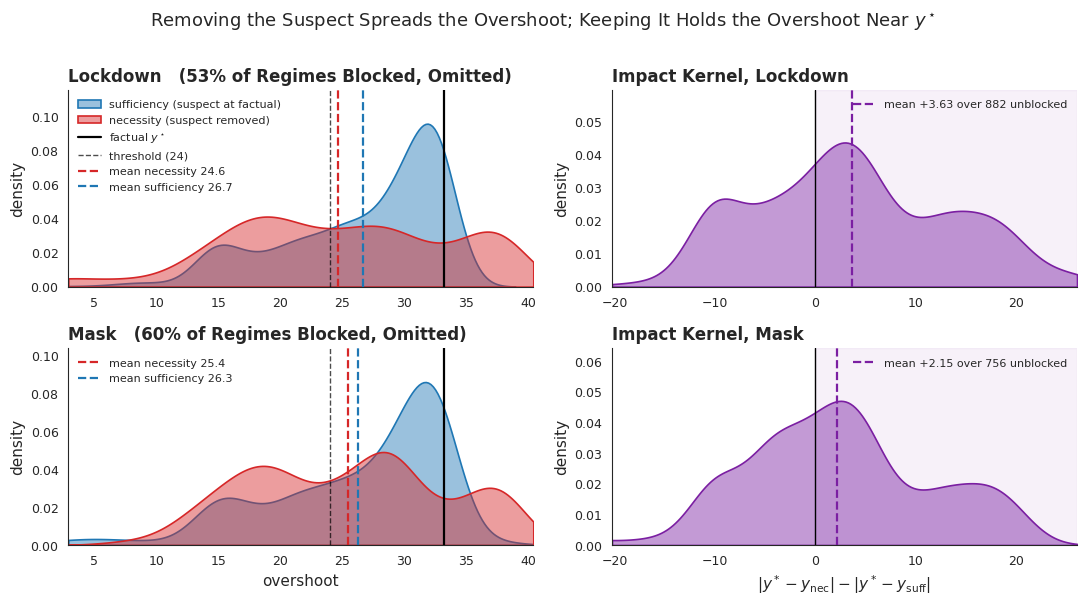

In [12]:
# Figure 2: per-suspect distributions under PCI thin search.
# Rows = suspects; col 0 = overshoot under suff/nec interventions; col 1 = score.
# A regime whose witness set blocks every path returns the same overshoot in both
# worlds, so it carries no information about the suspect and would swamp both
# panels. The figure shows the regimes where the flip reaches the outcome and
# reports the blocked share; the PCI score still averages over all of them.

NEC_COLOR = "#d62728"  # red
SUFF_COLOR = "#1f77b4"  # blue
SCORE_COLOR = "#7b1fa2"  # purple


import numpy as np


def _flatten_drop_nans(x: torch.Tensor) -> torch.Tensor:
    x = x.detach().cpu().flatten()
    return x[~torch.isnan(x)]


def _aligned(*tensors: torch.Tensor) -> list[np.ndarray]:
    """Flatten several per-regime tensors, dropping regimes any of them masks out."""
    flat = [t.detach().cpu().flatten() for t in tensors]
    keep = ~torch.stack([torch.isnan(t) for t in flat]).any(dim=0)
    return [t[keep].numpy() for t in flat]


def _density(values, ax, color, clip, label=None):
    """Filled KDE, falling back to a histogram when a smoke run leaves too few points."""
    if values.size > 5 and float(values.max() - values.min()) > 0:
        sns.kdeplot(
            x=values,
            ax=ax,
            color=color,
            fill=True,
            alpha=0.45,
            linewidth=1.2,
            clip=clip,
            label=label,
        )
    elif values.size > 0:
        sns.histplot(
            values,
            ax=ax,
            color=color,
            alpha=0.45,
            stat="density",
            binrange=clip,
            label=label,
        )


factual_overshoot_scalar = float(_flatten_drop_nans(factual_overshoot)[0].item())

n_rows = len(suspects)
fig, axs = plt.subplots(n_rows, 2, figsize=(11, 3.0 * n_rows))
if n_rows == 1:
    axs = axs.reshape(1, 2)

# common x-range for the suff/nec overshoot histograms (col 0)
all_outcome_vals = []
score_vals_per_suspect = {}
blocked_share_per_suspect = {}
for suspect_name in suspects:
    ss = condition_on_interventional_regime(
        results_dictionary=search_results,
        reference_variable_names=[suspect_name],
        antecedent_regimes={suspect_name: True},
        witness_regimes={suspect_name: False},
    )
    sc = abs_diff_score(
        suff_outcomes=ss["regime_sufficiency"]["overshoot"],
        nec_outcomes=ss["regime_necessity"]["overshoot"],
        factual_outcomes=factual_overshoot,
    )
    suff_all, nec_all, total_all = _aligned(
        ss["regime_sufficiency"]["overshoot"],
        ss["regime_necessity"]["overshoot"],
        sc["total"],
    )
    reaches = np.abs(nec_all - suff_all) > 1e-4
    blocked_share_per_suspect[suspect_name] = (
        1.0 - float(reaches.mean()) if reaches.size else 0.0
    )
    suff_vals, nec_vals = suff_all[reaches], nec_all[reaches]
    all_outcome_vals.append(suff_vals)
    all_outcome_vals.append(nec_vals)
    score_vals_per_suspect[suspect_name] = (suff_vals, nec_vals, total_all[reaches])

all_outcome = (
    np.concatenate([v for v in all_outcome_vals if v.size > 0])
    if all_outcome_vals
    else np.array([0.0, 1.0])
)
out_lo = float(np.nanpercentile(all_outcome, 1)) if all_outcome.size > 1 else 0.0
out_hi = float(np.nanpercentile(all_outcome, 99)) if all_outcome.size > 1 else 1.0
out_pad = 0.05 * (out_hi - out_lo + 1e-9)
out_lo -= out_pad
out_hi += out_pad

all_scores = (
    np.concatenate([v[2] for v in score_vals_per_suspect.values() if v[2].size > 0])
    if score_vals_per_suspect
    else np.array([-1.0, 1.0])
)
if all_scores.size == 0:
    all_scores = np.array([-1.0, 1.0])
score_lo = float(np.nanpercentile(all_scores, 1)) if all_scores.size > 1 else -1.0
score_hi = float(np.nanpercentile(all_scores, 99)) if all_scores.size > 1 else 1.0
score_pad = 0.05 * (score_hi - score_lo + 1e-9)
score_lo -= score_pad
score_hi += score_pad

for i, suspect_name in enumerate(suspects):
    suff_vals, nec_vals, total_scores = score_vals_per_suspect[suspect_name]

    # --- col 0: outcome distributions (suff vs nec)
    ax0 = axs[i, 0]
    _density(
        suff_vals,
        ax0,
        SUFF_COLOR,
        (out_lo, out_hi),
        label="sufficiency (suspect at factual)",
    )
    _density(
        nec_vals, ax0, NEC_COLOR, (out_lo, out_hi), label="necessity (suspect removed)"
    )
    ax0.axvline(
        factual_overshoot_scalar,
        color="black",
        linestyle="-",
        linewidth=1.6,
        label=r"factual $y^\star$",
    )
    ax0.axvline(
        overshoot_threshold,
        color="black",
        linestyle="--",
        linewidth=1.0,
        alpha=0.7,
        label=f"threshold ({overshoot_threshold})",
    )
    # Report the mean of each side, as the score panel does on the right. These go
    # in the legend rather than as free text, which would sit under the y* line.
    for vals, color, side in (
        (nec_vals, NEC_COLOR, "necessity"),
        (suff_vals, SUFF_COLOR, "sufficiency"),
    ):
        if vals.size == 0:
            continue
        ax0.axvline(
            float(vals.mean()),
            color=color,
            linestyle="--",
            linewidth=1.6,
            label=f"mean {side} {float(vals.mean()):.1f}",
        )
    ax0.set_ylim(top=ax0.get_ylim()[1] * 1.15)
    ax0.set_xlim(out_lo, out_hi)
    ax0.set_title(
        f"{suspect_name.capitalize()}   ({blocked_share_per_suspect[suspect_name]:.0%} of Regimes Blocked, Omitted)",
        loc="left",
        fontweight="bold",
    )
    ax0.set_xlabel("overshoot" if i == n_rows - 1 else "")
    ax0.set_ylabel("density")
    handles, labels = ax0.get_legend_handles_labels()
    if i != 0:
        # the four reference entries repeat across rows; keep only the two means
        kept = [(h, lb) for h, lb in zip(handles, labels) if lb.startswith("mean ")]
        handles, labels = [h for h, _ in kept], [lb for _, lb in kept]
    ax0.legend(handles, labels, loc="upper left", fontsize=8, frameon=False)

    # --- col 1: total score distribution, with positive region shaded
    ax1 = axs[i, 1]
    _density(total_scores, ax1, SCORE_COLOR, (score_lo, score_hi))
    ax1.axvline(0, color="black", linestyle="-", linewidth=1.0)
    ax1.axvspan(0, score_hi, alpha=0.06, color=SCORE_COLOR)
    # The mean of what is drawn here, over the unblocked regimes only. The PCI
    # score in the table is smaller: it keeps the blocked zeros and applies q^2.
    if total_scores.size > 0:
        ax1.axvline(
            float(total_scores.mean()),
            color=SCORE_COLOR,
            linestyle="--",
            linewidth=1.6,
            label=f"mean {float(total_scores.mean()):+.2f} "
            f"over {total_scores.size} unblocked",
        )
        ax1.legend(loc="upper right", fontsize=8, frameon=False)
    ax1.set_xlim(score_lo, score_hi)
    ax1.set_title(
        f"Impact Kernel, {suspect_name.capitalize()}", loc="left", fontweight="bold"
    )
    ax1.set_xlabel(
        r"$|y^* - y_{\mathrm{nec}}| - |y^* - y_{\mathrm{suff}}|$"
        if i == n_rows - 1
        else ""
    )
    ax1.set_ylabel("density")
    ax1.set_ylim(top=ax1.get_ylim()[1] * 1.3)

fig.suptitle(
    r"Removing the Suspect Spreads the Overshoot; Keeping It Holds the Overshoot Near $y^\star$",
    fontsize=13,
    y=1.005,
)
plt.tight_layout()
sns.despine()

if not smoke_test:
    os.makedirs(fig_dir, exist_ok=True)
    fig.savefig(os.path.join(fig_dir, "sir_pci_distributions.png"))
    print(f"Saved {os.path.join(fig_dir, 'sir_pci_distributions.png')}")

### Narrowing on the score gap sources

The two scores differ, but the per-regime kernel values overlap almost completely, so it
is worth asking which regimes carry the difference. Two thirds of the counting regimes name both
policies at once. In such a regime the necessity world flips lockdown and mask together and the
sufficiency world holds both at factual, so the regime produces one pair of
worlds and one kernel value. That value enters lockdown's average and mask's average as the same number,
from the same draw of $\beta$ and $\gamma$ and the same witness set. The
remaining third group focuses on single policy regimes, where the difference becomes clear.

Saved /home/rafal/s76projects/explainable_paper/docs/source/sir_benchmark/sir_heatmap.png


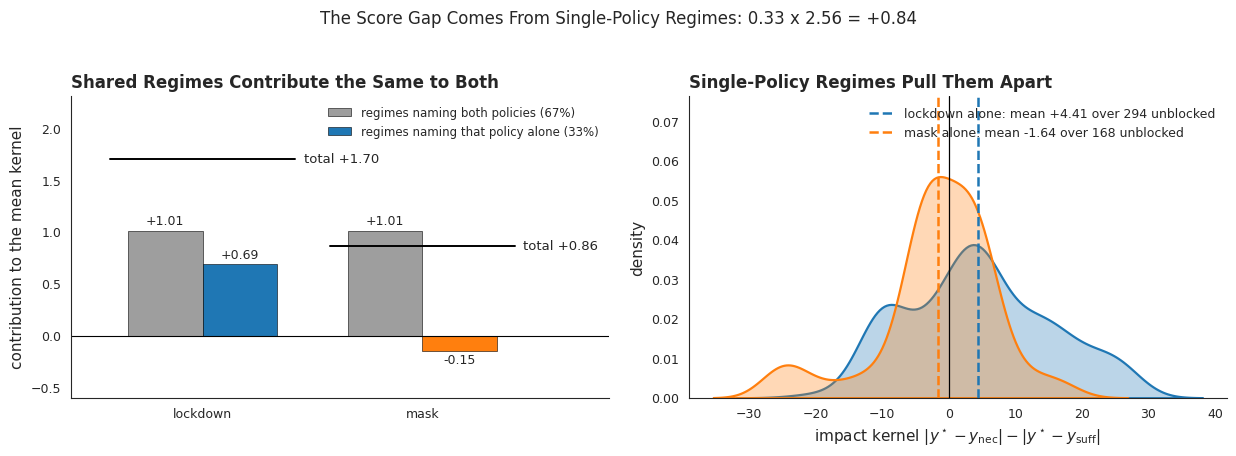

In [13]:
SUSPECT_COLORS = {"lockdown": "#1f77b4", "mask": "#ff7f0e"}
SHARED_COLOR = "#9e9e9e"

_ai, _wi = search_results.antecedent_indicators, search_results.witness_indicators
_partner = {"lockdown": "mask", "mask": "lockdown"}
kernel_all = (
    abs_diff_score(
        suff_outcomes=search_results.sufficiency["overshoot"],
        nec_outcomes=search_results.necessity["overshoot"],
        factual_outcomes=factual_overshoot,
    )["total"]
    .flatten()
    .numpy()
)
nec_all = search_results.necessity["overshoot"].flatten().numpy()
suff_all = search_results.sufficiency["overshoot"].flatten().numpy()
unblocked_all = np.abs(nec_all - suff_all) > 1e-4

shared_mask = (_ai["lockdown"] & _ai["mask"] & ~_wi["lockdown"] & ~_wi["mask"]).numpy()
alone_mask = {s: (_ai[s] & ~_ai[_partner[s]] & ~_wi[s]).numpy() for s in suspects}


def _cell_mean(values: np.ndarray) -> float:
    """Mean of a regime cell, or 0 when a smoke run leaves the cell empty."""
    return float(values.mean()) if values.size else 0.0


shared_mean = _cell_mean(kernel_all[shared_mask])
parts = {}
for s in suspects:
    n_cell = int(shared_mask.sum() + alone_mask[s].sum())
    w_alone = float(alone_mask[s].sum()) / n_cell if n_cell else 0.0
    parts[s] = {
        "w_alone": w_alone,
        "shared": (1 - w_alone) * shared_mean,
        "alone": w_alone * _cell_mean(kernel_all[alone_mask[s]]),
        "alone_mean": _cell_mean(kernel_all[alone_mask[s]]),
        "n_alone": int(alone_mask[s].sum()),
    }

fig, axs = plt.subplots(1, 2, figsize=(12.5, 4.4))

# (a) the decomposition of each suspect's mean kernel
ax = axs[0]
x_pos = np.arange(len(suspects))
bar_w = 0.34
ax.bar(
    x_pos - bar_w / 2,
    [parts[s]["shared"] for s in suspects],
    width=bar_w,
    color=SHARED_COLOR,
    edgecolor="black",
    linewidth=0.4,
    label=f"regimes naming both policies ({1 - parts[suspects[0]]['w_alone']:.0%})",
)
ax.bar(
    x_pos + bar_w / 2,
    [parts[s]["alone"] for s in suspects],
    width=bar_w,
    color=[SUSPECT_COLORS[s] for s in suspects],
    edgecolor="black",
    linewidth=0.4,
    label=f"regimes naming that policy alone ({parts[suspects[0]]['w_alone']:.0%})",
)
for j, s in enumerate(suspects):
    for off, key in ((-bar_w / 2, "shared"), (bar_w / 2, "alone")):
        v = parts[s][key]
        ax.text(
            x_pos[j] + off,
            v + (0.06 if v >= 0 else -0.12),
            f"{v:+.2f}",
            ha="center",
            fontsize=9,
        )
    total = parts[s]["shared"] + parts[s]["alone"]
    ax.plot([x_pos[j] - 0.42, x_pos[j] + 0.42], [total, total], color="black", lw=1.4)
    ax.text(
        x_pos[j] + 0.46,
        total,
        f"total {total:+.2f}",
        ha="left",
        va="center",
        fontsize=9.5,
    )
ax.axhline(0, color="black", lw=0.8)
ax.set_xlim(-0.6, len(suspects) - 0.15)
ax.set_xticks(x_pos)
ax.set_xticklabels(suspects)
ax.set_ylabel("contribution to the mean kernel")
ax.set_title(
    "Shared Regimes Contribute the Same to Both", loc="left", fontweight="bold"
)
_heights = [parts[s2][key] for s2 in suspects for key in ("shared", "alone")]
_heights += [parts[s2]["shared"] + parts[s2]["alone"] for s2 in suspects]
ax.set_ylim(bottom=min(_heights + [0.0]) - 0.45, top=max(_heights + [0.0]) * 1.3 + 0.1)
ax.legend(loc="upper right", fontsize=8.5, frameon=False)

# (b) the regimes that can separate them
ax = axs[1]
for s in suspects:
    vals = kernel_all[alone_mask[s] & unblocked_all]
    color = SUSPECT_COLORS[s]
    if vals.size > 5 and float(vals.max() - vals.min()) > 0:
        sns.kdeplot(x=vals, ax=ax, color=color, fill=True, alpha=0.30, linewidth=1.6)
    elif vals.size > 0:
        sns.histplot(vals, ax=ax, color=color, alpha=0.30, stat="density")
    if vals.size > 0:
        ax.axvline(
            float(vals.mean()),
            color=color,
            linestyle="--",
            linewidth=1.8,
            label=f"{s} alone: mean {float(vals.mean()):+.2f} "
            f"over {vals.size} unblocked",
        )
ax.axvline(0, color="black", lw=0.9)
ax.set_xlabel(r"impact kernel $|y^\star-y_{\mathrm{nec}}|-|y^\star-y_{\mathrm{suff}}|$")
ax.set_ylabel("density")
ax.set_title("Single-Policy Regimes Pull Them Apart", loc="left", fontweight="bold")
ax.set_ylim(top=ax.get_ylim()[1] * 1.3)
ax.legend(loc="upper right", fontsize=9, frameon=False)

gap = (parts["lockdown"]["shared"] + parts["lockdown"]["alone"]) - (
    parts["mask"]["shared"] + parts["mask"]["alone"]
)
fig.suptitle(
    f"The Score Gap Comes From Single-Policy Regimes: {parts['lockdown']['w_alone']:.2f} x {parts['lockdown']['alone_mean'] - parts['mask']['alone_mean']:.2f} = {gap:+.2f}",
    fontsize=12,
    y=1.03,
)
plt.tight_layout()
sns.despine()

if not smoke_test:
    os.makedirs(fig_dir, exist_ok=True)
    fig.savefig(os.path.join(fig_dir, "sir_heatmap.png"))
    print(f"Saved {os.path.join(fig_dir, 'sir_heatmap.png')}")

The left panel splits each suspect's mean kernel into those two parts. The shared part is
$+1.01$ for both, because it is the same regimes and the same numbers. The
single-policy part is $+0.69$ for lockdown and $-0.15$ for mask, and the totals, $+1.70$
and $+0.86$, are the third column of the table above.

The gap is due to the single-policy regimes:
$0.33 \times (+2.11 - (-0.45)) = +0.84$, against an observed gap of $+0.84$. The right
panel shows those regimes. Naming lockdown alone scores $+4.41$ on average over the
unblocked ones, naming mask alone $-1.64$.


### Robustness across factual worlds

Everything so far conditions on one factual world, at one draw of $\beta$ and $\gamma$.
The next cell repeats the analysis on $20$ worlds, each with both policies enacted, as
in the single-world case, and each with its own draw of the rates. Holding the policy
configuration fixed keeps the question the same from world to world; what varies is the
operating point of the epidemic, and with it the factual overshoot the suspects are
being scored against. Each world gets $200$ regimes, and every world sees the same
regimes, so the lockdown-versus-mask comparison is paired within a world.

Loaded cache /home/rafal/s76projects/explainable_paper/docs/source/dynamical_benchmark/search_many_worlds20_n200_seed123.pkl
worlds: 20, regimes per world: 200
rate draws across worlds: beta 0.0160 to 0.0398, gamma 0.481 to 0.525
factual overshoot across worlds: 9.86 to 33.80, 12 above the threshold
  lockdown  mean PCI across worlds +0.819
  mask      mean PCI across worlds +0.118
  lockdown - mask: mean +0.701 (se 0.111), lockdown ahead in 18/20 worlds


Saved /home/rafal/s76projects/explainable_paper/docs/source/sir_benchmark/sir_many_worlds.png


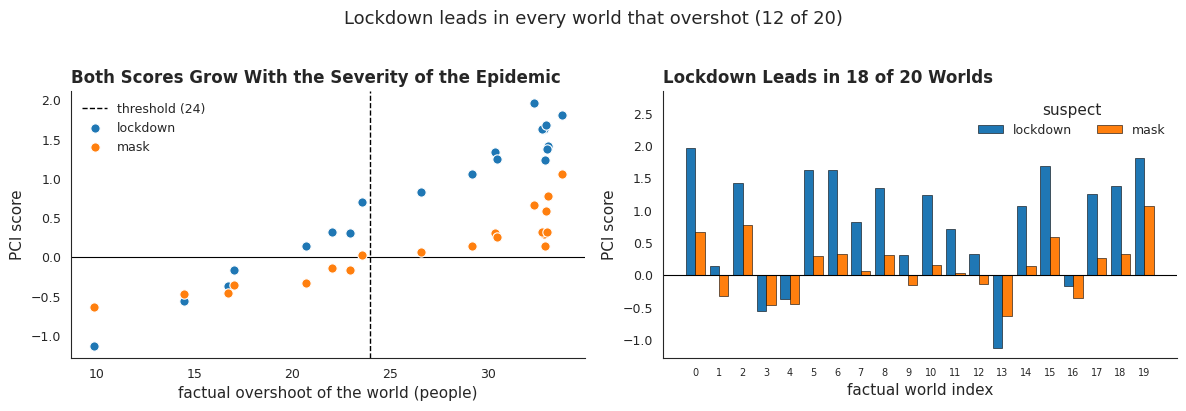

In [14]:
# Figure 4: robustness across factual worlds. Every world here has both
# policies enacted, as in the single-world analysis; what varies across worlds
# is the operating point, since bayesian_sir now draws beta and gamma per world.


def _as_float(x: torch.Tensor) -> torch.Tensor:
    return x.detach().float()


num_factual_worlds = num_worlds_at_site
num_search_samples_many = 5 if smoke_test else 200

cache_path_many = os.path.join(
    results_dir,
    f"search_many_worlds{num_factual_worlds}_n{num_search_samples_many}_seed{seed}.pkl",
)

if (not smoke_test) and (not fresh_run) and os.path.exists(cache_path_many):
    with open(cache_path_many, "rb") as f:
        (
            search_results_many,
            factual_overshoot_many,
            obs_dict_many,
            factual_beta_many,
            factual_gamma_many,
        ) = pickle.load(f)
    print(f"Loaded cache {cache_path_many}")
else:
    obs_dict_many = {
        "continuous": {
            "lockdown_efficiency": torch.full((num_factual_worlds, 1, 1), 0.6),
            "mask_efficiency": torch.full((num_factual_worlds, 1, 1), 0.1),
            "joint_efficiency": torch.full((num_factual_worlds, 1, 1), 0.7),
        },
        "categorical": {
            "lockdown": torch.ones(num_factual_worlds, 1, 1, dtype=torch.long),
            "mask": torch.ones(num_factual_worlds, 1, 1, dtype=torch.long),
        },
    }

    with torch.no_grad():
        with pyro.poutine.trace() as tr_worlds:
            searchable_overshoot_model(
                kwargs_iterable=[
                    {
                        "observations_dict": obs_dict_many,
                        "n_size": num_factual_worlds,
                    },
                    {},
                    {},
                ]
            )

    factual_beta_many = _as_float(
        cast(torch.Tensor, tr_worlds.trace.nodes["beta"]["value"])
    )
    factual_gamma_many = _as_float(
        cast(torch.Tensor, tr_worlds.trace.nodes["gamma"]["value"])
    )
    factual_overshoot_many = _as_float(
        cast(torch.Tensor, tr_worlds.trace.nodes["overshoot"]["value"])
    )

    sampler_many = ThinSearchSampler(
        structured_model=searchable_model,
        conditioned_alternatives=True,
        factual_exclusion=True,
        max_antecedents=4,
        max_witnesses_dropped=4,
    )

    search_results_many = sampler_many.sample(
        obs_dict_many, num_samples=num_search_samples_many
    )

    if not smoke_test:
        os.makedirs(results_dir, exist_ok=True)
        with open(cache_path_many, "wb") as f:  # type: ignore[assignment]  # f rebound to writer in else-branch
            pickle.dump(
                (
                    search_results_many,
                    factual_overshoot_many,
                    obs_dict_many,
                    factual_beta_many,
                    factual_gamma_many,
                ),
                f,
            )
        print(f"Wrote cache {cache_path_many}")


def _pci_per_world(scores_total: torch.Tensor) -> torch.Tensor:
    """Per-world PCI score: q^2 times the mean kernel over the regimes that count."""
    t = scores_total.detach().cpu()
    t = t.reshape(t.shape[0], t.shape[1], -1)
    kept = (~torch.isnan(t)).sum(dim=(0, 2)).float()
    q = kept / num_search_samples_many
    return q**2 * torch.nanmean(t, dim=(0, 2))


total_per_world_per_suspect = {}
for suspect_name in suspects:
    ss = condition_on_interventional_regime(
        results_dictionary=search_results_many,
        reference_variable_names=[suspect_name],
        antecedent_regimes={suspect_name: True},
        witness_regimes={suspect_name: False},
    )
    sc = abs_diff_score(
        suff_outcomes=ss["regime_sufficiency"]["overshoot"],
        nec_outcomes=ss["regime_necessity"]["overshoot"],
        factual_outcomes=factual_overshoot_many,
    )
    total_per_world_per_suspect[suspect_name] = _pci_per_world(sc["total"]).numpy()

import numpy as np

factual_over_flat = (
    factual_overshoot_many.detach().cpu().reshape(num_factual_worlds, -1).mean(dim=1)
)
world_gap = (
    total_per_world_per_suspect["lockdown"] - total_per_world_per_suspect["mask"]
)
n_lockdown_wins = int((world_gap > 0).sum())
gap_se = (
    float(np.std(world_gap, ddof=1) / np.sqrt(len(world_gap)))
    if len(world_gap) > 1
    else float("nan")
)

print(f"worlds: {num_factual_worlds}, regimes per world: {num_search_samples_many}")
print(
    f"rate draws across worlds: "
    f"beta {float(factual_beta_many.min()):.4f} to {float(factual_beta_many.max()):.4f}, "
    f"gamma {float(factual_gamma_many.min()):.3f} to {float(factual_gamma_many.max()):.3f}"
)
print(
    f"factual overshoot across worlds: "
    f"{float(factual_over_flat.min()):.2f} to {float(factual_over_flat.max()):.2f}, "
    f"{int((factual_over_flat > overshoot_threshold).sum())} above the threshold"
)
for suspect_name in suspects:
    print(
        f"  {suspect_name:9s} mean PCI across worlds "
        f"{float(np.mean(total_per_world_per_suspect[suspect_name])):+.3f}"
    )
print(
    f"  lockdown - mask: mean {float(np.mean(world_gap)):+.3f} "
    f"(se {gap_se:.3f}), lockdown ahead in {n_lockdown_wins}/{num_factual_worlds} worlds"
)

SUSPECT_COLORS = {"lockdown": "#1f77b4", "mask": "#ff7f0e"}

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Score against the severity of the world it was computed in: what a suspect gets
# depends on how much excess overshoot there was to attribute in the first place.
axs[0].axhline(0, color="black", linewidth=0.8)
axs[0].axvline(
    overshoot_threshold,
    color="black",
    linestyle="--",
    linewidth=1.0,
    label=f"threshold ({overshoot_threshold})",
)
for suspect_name in suspects:
    axs[0].scatter(
        factual_over_flat.numpy(),
        total_per_world_per_suspect[suspect_name],
        s=45,
        color=SUSPECT_COLORS.get(suspect_name, None),
        edgecolor="white",
        linewidth=0.8,
        zorder=3,
        label=suspect_name,
    )
axs[0].set_title(
    "Both Scores Grow With the Severity of the Epidemic",
    loc="left",
    fontweight="bold",
)
axs[0].set_xlabel("factual overshoot of the world (people)")
axs[0].set_ylabel("PCI score")
axs[0].legend(loc="upper left", frameon=False, fontsize=9)

worlds = np.arange(num_factual_worlds)
bar_w = 0.4
for j, suspect_name in enumerate(suspects):
    offset = (j - (len(suspects) - 1) / 2.0) * bar_w
    axs[1].bar(
        worlds + offset,
        total_per_world_per_suspect[suspect_name],
        width=bar_w,
        color=SUSPECT_COLORS.get(suspect_name, None),
        edgecolor="black",
        linewidth=0.4,
        label=suspect_name,
    )
axs[1].axhline(0, color="black", linewidth=0.8)
axs[1].set_title(
    f"Lockdown Leads in {n_lockdown_wins} of {num_factual_worlds} Worlds",
    loc="left",
    fontweight="bold",
)
axs[1].set_xlabel("factual world index")
axs[1].set_ylabel("PCI score")
axs[1].set_xticks(worlds)
axs[1].tick_params(axis="x", labelsize=7)
bar_top = max(float(np.max(v)) for v in total_per_world_per_suspect.values())
axs[1].set_ylim(top=bar_top * 1.45)
axs[1].legend(title="suspect", frameon=False, loc="upper right", ncol=2)

overshot = factual_over_flat.numpy() > overshoot_threshold
n_overshot = int(overshot.sum())
n_lead_overshot = int((world_gap[overshot] > 0).sum())
headline = (
    f"Lockdown leads in every world that overshot "
    f"({n_overshot} of {num_factual_worlds})"
    if n_lead_overshot == n_overshot
    else f"Lockdown leads in {n_lead_overshot} of the {n_overshot} worlds that overshot"
)
fig.suptitle(headline, fontsize=13, y=1.02)
plt.tight_layout()
sns.despine()

if not smoke_test:
    os.makedirs(fig_dir, exist_ok=True)
    fig.savefig(os.path.join(fig_dir, "sir_many_worlds.png"))
    print(f"Saved {os.path.join(fig_dir, 'sir_many_worlds.png')}")

The transmission rate $\beta$ runs from $0.016$ to $0.040$ across the sampled worlds,
which carries the factual overshoot from $9.9$ to $33.8$ people and puts $12$ of the $20$
past the $24$ threshold. The left panel plots each world's two scores against its factual
overshoot. Both rise with it, lockdown faster, and both go negative in the mildest worlds,
where there is no excess overshoot to attribute to anything.

Lockdown's score exceeds mask's in $18$ of the $20$ worlds. Averaged over worlds the
PCI scores are $0.82$ for lockdown and $0.12$ for mask, and the per-world gap is $0.70$
with a standard error of $0.11$ across worlds.


### Mask counts as a cause only when its partner can adapt

The two policies reach the epidemic through their efficiencies, and those efficiencies
are entangled: masking is worth $0.45$ on its own and only $0.1$ once lockdown is in
force. So removing lockdown does two things at once. It takes away lockdown's own
impact on the infections, and it lets masking step up from $0.1$ to
$0.45$ to replace some of it.

The witness set decides whether the counterfactual world is allowed that second move.
Pin the partner's efficiency as a witness and it stays frozen at its factual value;
leave it out of the witness set and it adapts. We can now look at what happens in those
two types of regimes. As expected, witness pinning reveals the asymmetry here.

 suspect         context_var         context  n_regimes  Pr(overshoot>thr | nec)  mean nec  mean suff  score_nec  score_suff   mean ci        q       PCI
lockdown     mask_efficiency fixed (witness)       1143                 0.622922 26.093012  26.408207   7.677070   -6.811058  0.866012 0.754954  0.493588
lockdown     mask_efficiency            free        741                 0.616734 25.054274  27.020243   9.201074   -6.218636  2.982438 0.751521  1.684434
    mask lockdown_efficiency fixed (witness)       1157                 0.730337 26.656889  26.379452   6.563541   -6.843892 -0.280351 0.758689 -0.161372
    mask lockdown_efficiency            free        729                 0.547325 25.702343  27.009310   9.078699   -6.401577  2.677121 0.747692  1.496628


Saved /home/rafal/s76projects/explainable_paper/docs/source/sir_benchmark/sir_contexts.png


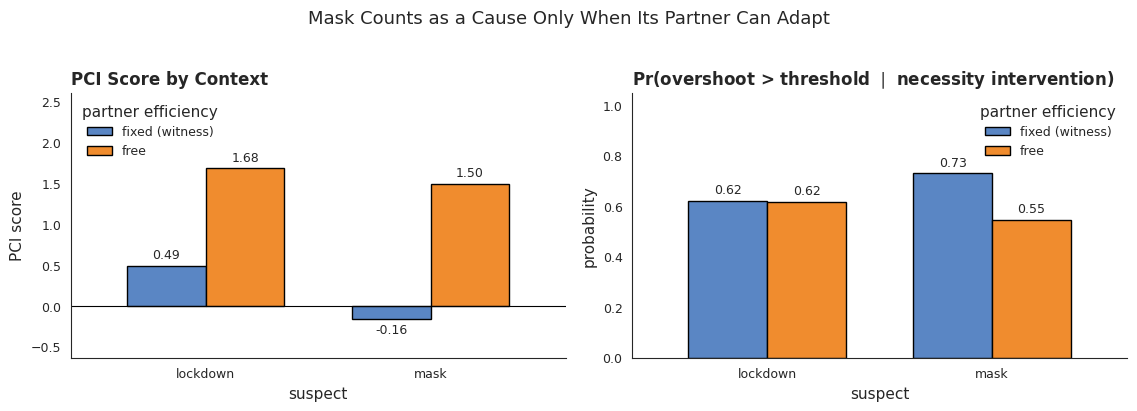

In [15]:
# Figure 5: different-contexts experiment.
# How does fixing the partner-policy efficiency variable as a witness change the
# necessity-side outcome and the resulting PCI score for each suspect?

contexts = [
    ("lockdown", "mask_efficiency"),
    ("mask", "lockdown_efficiency"),
]

ctx_rows = []
for suspect_name, ctx_var in contexts:
    for ctx_label, ctx_flag in [("fixed (witness)", True), ("free", False)]:
        sample = condition_on_interventional_regime(
            results_dictionary=search_results,
            reference_variable_names=[suspect_name, ctx_var],
            antecedent_regimes={suspect_name: True},
            witness_regimes={suspect_name: False, ctx_var: ctx_flag},
        )
        bucket = (
            search_results.witness_indicators[ctx_var]
            if ctx_flag
            else ~search_results.witness_indicators[ctx_var]
        )
        n_bucket = int(bucket.sum().item())
        nec_t = sample["regime_necessity"]["overshoot"].detach().cpu().flatten()
        suff_t = sample["regime_sufficiency"]["overshoot"].detach().cpu().flatten()
        keep = ~(torch.isnan(nec_t) | torch.isnan(suff_t))
        n_kept = int(keep.sum().item())
        if n_kept > 0:
            nec_vals = nec_t[keep]
            suff_vals = suff_t[keep]
            pr_too_high_nec = float(
                (nec_vals > overshoot_threshold).float().mean().item()
            )
            mean_nec = float(nec_vals.mean().item())
            mean_suff = float(suff_vals.mean().item())
            scores = abs_diff_score(
                suff_outcomes=sample["regime_sufficiency"]["overshoot"],
                nec_outcomes=sample["regime_necessity"]["overshoot"],
                factual_outcomes=factual_overshoot,
            )
            score_total = float(torch.nanmean(scores["total"]).item())
            score_nec = float(torch.nanmean(scores["nec"]).item())
            score_suff = float(torch.nanmean(scores["suff"]).item())
            # Each context is a different choice of Gamma, so the mass is taken
            # within the bucket: of the regimes this Gamma can draw, the share
            # that puts the suspect in the candidate cause set.
            q_ctx = n_kept / n_bucket if n_bucket else float("nan")
            pci = q_ctx**2 * score_total
        else:
            pr_too_high_nec = float("nan")
            mean_nec = float("nan")
            mean_suff = float("nan")
            score_total = float("nan")
            q_ctx = float("nan")
            pci = float("nan")
            score_nec = float("nan")
            score_suff = float("nan")
        ctx_rows.append(
            {
                "suspect": suspect_name,
                "context_var": ctx_var,
                "context": ctx_label,
                "n_regimes": n_kept,
                "Pr(overshoot>thr | nec)": pr_too_high_nec,
                "mean nec": mean_nec,
                "mean suff": mean_suff,
                "score_nec": score_nec,
                "score_suff": score_suff,
                "mean ci": score_total,
                "q": q_ctx,
                "PCI": pci,
            }
        )

ctx_df = pd.DataFrame(ctx_rows)
print(ctx_df.to_string(index=False))

CONTEXT_COLORS = {"fixed (witness)": "#5a86c4", "free": "#f08c2e"}

fig, axs = plt.subplots(1, 2, figsize=(11.5, 4))

score_pivot = ctx_df.pivot(index="suspect", columns="context", values="PCI")
score_pivot = score_pivot[["fixed (witness)", "free"]]
ax_score = score_pivot.plot(
    kind="bar",
    ax=axs[0],
    color=[CONTEXT_COLORS["fixed (witness)"], CONTEXT_COLORS["free"]],
    edgecolor="black",
    width=0.7,
    legend=False,
)
for container in ax_score.containers:
    ax_score.bar_label(container, fmt="%.2f", padding=3, fontsize=9)
axs[0].axhline(0, color="black", linewidth=0.8)
axs[0].set_title("PCI Score by Context", loc="left", fontweight="bold")
axs[0].set_ylabel("PCI score")
axs[0].set_xlabel("suspect")
axs[0].tick_params(axis="x", rotation=0)
# Headroom at both ends so the bar labels clear the axis line, and finite-only so
# an empty smoke-run bucket cannot hand set_ylim a NaN.
score_finite = score_pivot.to_numpy()[np.isfinite(score_pivot.to_numpy())]
score_top = float(score_finite.max()) if score_finite.size else 1.0
score_bottom = float(score_finite.min()) if score_finite.size else 0.0
score_span = max(abs(score_top), abs(score_bottom), 0.1)
axs[0].set_ylim(bottom=min(0.0, score_bottom) - 0.28 * score_span, top=score_top * 1.55)
axs[0].legend(title="partner efficiency", frameon=False, loc="upper left")

pr_pivot = ctx_df.pivot(
    index="suspect", columns="context", values="Pr(overshoot>thr | nec)"
)
pr_pivot = pr_pivot[["fixed (witness)", "free"]]
ax_pr = pr_pivot.plot(
    kind="bar",
    ax=axs[1],
    color=[CONTEXT_COLORS["fixed (witness)"], CONTEXT_COLORS["free"]],
    edgecolor="black",
    width=0.7,
    legend=False,
)
for container in ax_pr.containers:
    ax_pr.bar_label(container, fmt="%.2f", padding=3, fontsize=9)
axs[1].set_title(
    r"Pr(overshoot > threshold $\mid$ necessity intervention)",
    loc="left",
    fontweight="bold",
)
axs[1].set_ylabel("probability")
axs[1].set_xlabel("suspect")
axs[1].set_ylim(0, 1.05)
axs[1].tick_params(axis="x", rotation=0)
axs[1].legend(title="partner efficiency", frameon=False)

fig.suptitle(
    "Mask Counts as a Cause Only When Its Partner Can Adapt",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
sns.despine()

if not smoke_test:
    os.makedirs(fig_dir, exist_ok=True)
    fig.savefig(os.path.join(fig_dir, "sir_contexts.png"))
    print(f"Saved {os.path.join(fig_dir, 'sir_contexts.png')}")

## Conclusions

On the single factual world PCI ranks lockdown above mask, $0.965$ against $0.491$, a
gap of about four Monte Carlo standard errors.  Across $20$ factual worlds spanning overshoots from $9.9$ to $33.8$ people, lockdown leads in $18$, with a mean gap of $0.70$ and a standard error of $0.11$. The two
exceptions are worlds whose epidemics never overshot, and there both suspects score
negative.

The contexts experiment says more about where the asymmetry comes from. Each context is a different choice of the regime
distribution, so each is scored with its own $q$. With the partner efficiency pinned as a
witness, lockdown still scores positive ($0.49$) while mask turns negative ($-0.16$);
with the partner free, lockdown rises to $1.68$ and mask to $1.50$.